# Computer Vision Tutorial: Multilayer Perceptron (MLP) - CIFAR-100 Coarse Classification

*   Adapt from the guided book chapter 3.1 "Image Classification using MLP"

---

In this notebook, we train a MLP to classify images from the CIFAR-100 database using the 20 coarse categories.

## Requirements
- **Point 1 (0.75 pt):** Train and evaluate at least 3 models using CIFAR-100 coarse labels with different epochs and learning rates
- **Point 2 (1.75 pt):** Add early stopping, design new MLP architecture, implement data augmentation, and compare results

## 1. Load CIFAR-100 Coarse Dataset

*   Dataset description available at: https://www.cs.toronto.edu/~kriz/cifar.html
*   Also, it is available at: https://keras.io/api/datasets/cifar100/
*   Contains 60,000 training images and 10,000 test images of 32x32 pixels
*   We use 20 coarse categories instead of 100 fine categories

In [1]:
import keras
from keras.datasets import cifar100

# load the pre-shuffled train and test data (coarse labels: 20 categories)
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='coarse')

I0000 00:00:1773132579.599159   10133 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773132580.744447   10133 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773132583.650968   10133 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/ervin/Videos/taller-1-/venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## 2. Visualize the First 24 Training Images from CIFAR-100

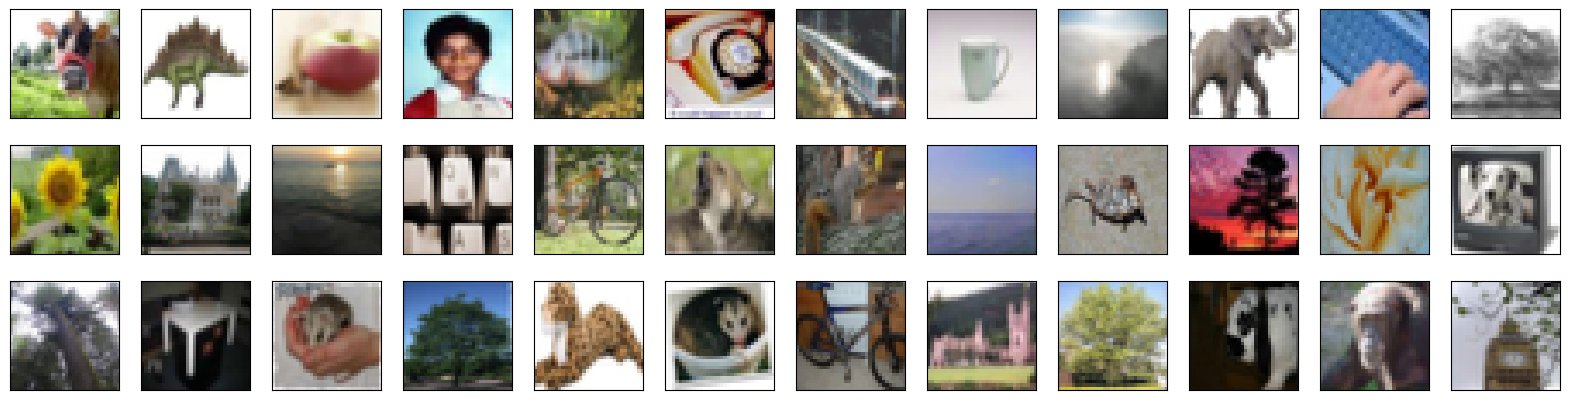

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_train[i]))

## 3. **Image preprocessing**

### 3.1. Rescale the Images by Dividing Every Pixel in Every Image by 255
In fact, the cost function has the shape of a bowl, but it can be an elongated bowl if the features have very
different scales. Figure below shows Gradient Descent on a training set where features 1 and 2 have the
same scale (on the left), and on a training set where feature 1 has much smaller values than feature 2 (on
the right).

**Tip:** When using Gradient Descent, you should ensure that all features have a similar scale to speed up training or else it will take much longer to converge.


### 3.2. Data Augmentation

In [3]:
# rescale [0,255] --> [0,1]
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [ ]:
# Data Augmentation using TensorFlow's ImageDataGenerator
try:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
except ImportError:
    from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

## 4. Label Names and One-Hot Encoding for CIFAR-100 Coarse Classes

## 5. CIFAR-100 Coarse Category Labels

## 6. Define the MLP Model Architecture

The MLP neural network for CIFAR-100 coarse classification will take flattened images as input (32x32x3 = 3072 features) and output 20 class probabilities. We will create multiple architectures with different numbers of layers and neurons to compare their performance.

## 7. Compile the Model

In [ ]:
# Create function to build MLP models with different architectures
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras.optimizers import RMSprop, Adam, SGD

def build_mlp_model(input_shape, num_classes, architecture='standard'):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    
    if architecture == 'standard':
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(256, activation='relu'))
        model.add(Dropout(0.2))
        
    elif architecture == 'deep':
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(256, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(128, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(0.2))
        
    elif architecture == 'wide':
        model.add(Dense(1024, activation='relu'))
        model.add(Dropout(0.3))
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.3))
    
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print("MLP Model Architecture Descriptions:")
print("- Standard: 2 layers (512, 256 neurons) with Dropout 0.2")
print("- Deep: 4 layers (512, 256, 128, 64 neurons) with Dropout 0.2")
print("- Wide: 2 layers (1024, 512 neurons) with Dropout 0.3")

MLP Model Architecture Descriptions:
- Standard: 2 layers (512, 256 neurons) with Dropout 0.2
- Deep: 4 layers (512, 256, 128, 64 neurons) with Dropout 0.2
- Wide: 2 layers (1024, 512 neurons) with Dropout 0.3


### 4. Define the MLP Model Architecture



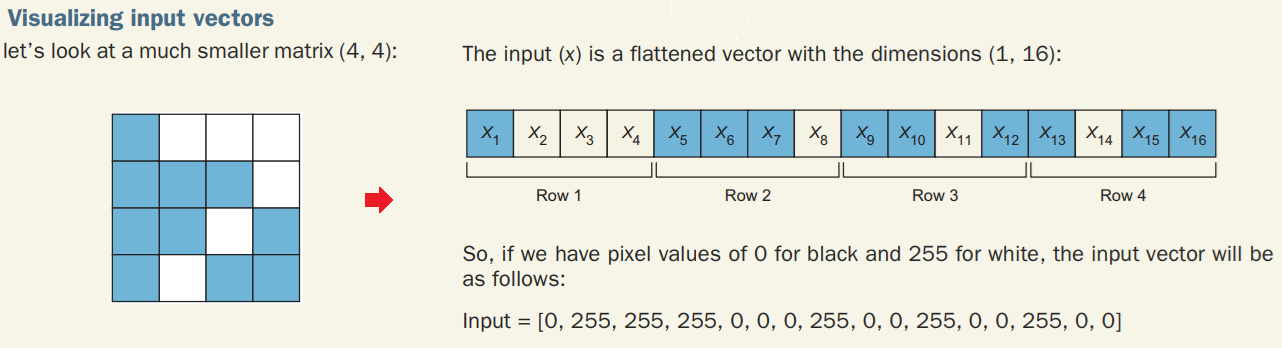

The MLP neural network we create by combining the input, hidden, and output layers

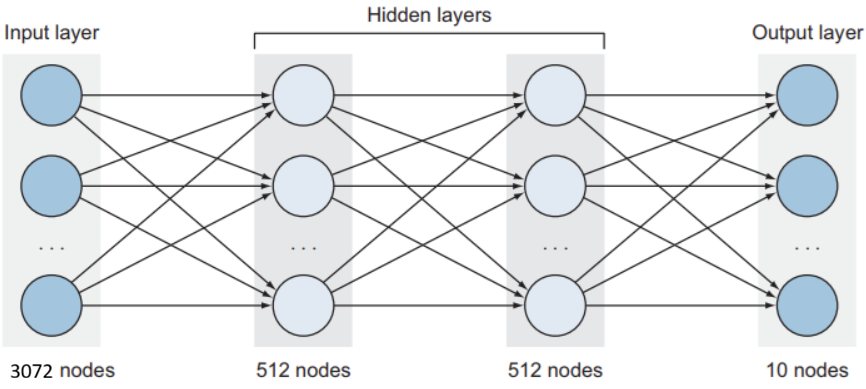

In [6]:
# CIFAR-100 coarse category labels (20 classes)
cifar100_coarse_labels = [
    'aquatic mammals',
    'fish',
    'flowers',
    'food containers',
    'fruit and vegetables',
    'household electrical devices',
    'household furniture',
    'insects',
    'large carnivores',
    'large man-made outdoor things',
    'large natural outdoor scenes',
    'large omnivores and herbivores',
    'medium-sized mammals',
    'non-insect invertebrates',
    'people',
    'reptiles',
    'small mammals',
    'trees',
    'vehicles 1',
    'vehicles 2'
]

## POINT 1: Training with CIFAR-100 Coarse Labels (0.75 points)

### 1a. Base Model with CIFAR-100 Coarse Labels

We will train the standard MLP model using different learning rates and epochs to understand their impact on model performance.
For CIFAR-100, we use categorical crossentropy loss and monitor accuracy.

In [7]:
# Prepare data: Normalize and one-hot encode labels
from keras.utils import to_categorical

# Split into training and validation sets (80-20 split)
num_validation_samples = 10000
x_valid = x_train[-num_validation_samples:]
y_valid = y_train[-num_validation_samples:]
x_train = x_train[:-num_validation_samples]
y_train = y_train[:-num_validation_samples]

# One-hot encode labels
num_classes = 20  # CIFAR-100 coarse has 20 classes
y_train = to_categorical(y_train, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"Training set shape: {x_train.shape}")
print(f"Validation set shape: {x_valid.shape}")
print(f"Test set shape: {x_test.shape}")
print(f"Number of classes: {num_classes}")

Training set shape: (40000, 32, 32, 3)
Validation set shape: (10000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Number of classes: 20


### 1b. Train 3 Models with Different Hyperparameters

Training 3 models with different epochs and learning rates to evaluate their performance on CIFAR-100 coarse classification.

In [8]:
# Define training configurations for Point 1.b
# Store models and histories for later comparison
models_point1 = {}
histories_point1 = {}
test_scores_point1 = {}

# Configuration 1: Model 1 - Standard architecture, 50 epochs, learning rate 0.001
print("=" * 60)
print("POINT 1: Model 1 - Standard Architecture")
print("Configuration: epochs=50, learning_rate=0.001")
print("=" * 60)

model1 = build_mlp_model((32, 32, 3), num_classes, architecture='standard')
model1.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

print(model1.summary())
hist1 = model1.fit(
    x_train, y_train,
    batch_size=128,
    epochs=50,
    verbose=1,
    validation_data=(x_valid, y_valid)
)

models_point1['Model1'] = model1
histories_point1['Model1'] = hist1
score1 = model1.evaluate(x_test, y_test, verbose=0)
test_scores_point1['Model1'] = score1[1]
print(f"\nModel 1 - Test Accuracy: {score1[1]:.4f}")


POINT 1: Model 1 - Standard Architecture
Configuration: epochs=50, learning_rate=0.001


/home/ervin/Videos/taller-1-/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1773132590.227790   10133 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773132590.228432   10167 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1773132590.241996   10133 cuda_executor.cc:1827] Nvml call failed with 3(Not Supported). Assuming PCIe gen 3 x16 bandwidth.
W0000 00:00:1773132590.243345   10133 gpu_device.cc:2365] Cannot dlopen some GPU librar

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,709,844 (6.52 MB)

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1054 - loss: 3.1904

W0000 00:00:1773132599.147318   10133 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.1353 - loss: 2.8481 - val_accuracy: 0.1458 - val_loss: 2.8490
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.1880 - loss: 2.6093 - val_accuracy: 0.2226 - val_loss: 2.5391
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.2147 - loss: 2.5301 - val_accuracy: 0.2195 - val_loss: 2.5199
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.2321 - loss: 2.4779 - val_accuracy: 0.2661 - val_loss: 2.4005
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.2444 - loss: 2.4449 - val_accuracy: 0.2805 - val_loss: 2.3531
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.2512 - loss: 2.4130 - val_accuracy: 0.2686 - val_loss: 2.3434
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.2629 - loss: 2.3853 - val_accuracy: 0.2889 - val_loss: 2.3199
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.2646 - loss: 2.3739 - val_accuracy: 0.28

W0000 00:00:1773133046.716563   10133 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.



Model 1 - Test Accuracy: 0.3154


### 1b. Learning Curves Comparison for Models 1, 2, and 3

Plot and compare the loss and accuracy curves for the three models trained with different hyperparameters.

In [9]:
# Configuration 2: Model 2 - Standard architecture, 40 epochs, learning rate 0.001
print("\n" + "=" * 60)
print("POINT 1: Model 2 - Standard Architecture")
print("Configuration: epochs=40, learning_rate=0.001")
print("=" * 60)

model2 = build_mlp_model((32, 32, 3), num_classes, architecture='standard')
model2.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

hist2 = model2.fit(
    x_train, y_train,
    batch_size=128,
    epochs=40,
    verbose=1,
    validation_data=(x_valid, y_valid)
)

models_point1['Model2'] = model2
histories_point1['Model2'] = hist2
score2 = model2.evaluate(x_test, y_test, verbose=0)
test_scores_point1['Model2'] = score2[1]
print(f"\nModel 2 - Test Accuracy: {score2[1]:.4f}")



POINT 1: Model 2 - Standard Architecture
Configuration: epochs=40, learning_rate=0.001
Epoch 1/40


W0000 00:00:1773133048.535457   10133 cpu_allocator_impl.cc:82] Allocation of 491520000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1064 - loss: 3.2156

W0000 00:00:1773133057.780262   10133 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.1372 - loss: 2.8533 - val_accuracy: 0.1817 - val_loss: 2.6458
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.1922 - loss: 2.6062 - val_accuracy: 0.2452 - val_loss: 2.4648
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.2167 - loss: 2.5267 - val_accuracy: 0.2517 - val_loss: 2.4388
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2336 - loss: 2.4765 - val_accuracy: 0.2507 - val_loss: 2.4432
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.2442 - loss: 2.4334 - val_accuracy: 0.2676 - val_loss: 2.3753
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.2538 - loss: 2.4087 - val_accuracy: 0.2798 - val_loss: 2.3384
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.2627 - loss: 2.3863 - val_accuracy: 0.2848 - val_loss: 2.3162
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.2653 - loss: 2.3650 - val_accuracy: 0.

In [10]:
# Configuration 3: Model 3 - Standard architecture, 50 epochs, learning rate 0.005
print("\n" + "=" * 60)
print("POINT 1: Model 3 - Standard Architecture")
print("Configuration: epochs=50, learning_rate=0.005")
print("=" * 60)

model3 = build_mlp_model((32, 32, 3), num_classes, architecture='standard')
model3.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(learning_rate=0.005),
    metrics=['accuracy']
)

hist3 = model3.fit(
    x_train, y_train,
    batch_size=128,
    epochs=50,
    verbose=1,
    validation_data=(x_valid, y_valid)
)

models_point1['Model3'] = model3
histories_point1['Model3'] = hist3
score3 = model3.evaluate(x_test, y_test, verbose=0)
test_scores_point1['Model3'] = score3[1]
print(f"\nModel 3 - Test Accuracy: {score3[1]:.4f}")



POINT 1: Model 3 - Standard Architecture
Configuration: epochs=50, learning_rate=0.005
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.0804 - loss: 3.7309 - val_accuracy: 0.0889 - val_loss: 3.0512
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.1155 - loss: 2.8114 - val_accuracy: 0.1072 - val_loss: 2.7991
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1244 - loss: 2.7765 - val_accuracy: 0.1178 - val_loss: 2.8153
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.1340 - loss: 2.7622 - val_accuracy: 0.1568 - val_loss: 2.7031
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.1364 - loss: 2.7530 - val_accuracy: 0.1626 - val_loss: 2.6701
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1429 - loss: 2.7438 - val_accuracy: 0.1307 - val_loss: 2.7079
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.1417 - loss: 2.7409 - val_accuracy: 0.1610 - val_loss: 2.6650
Epoch 8/

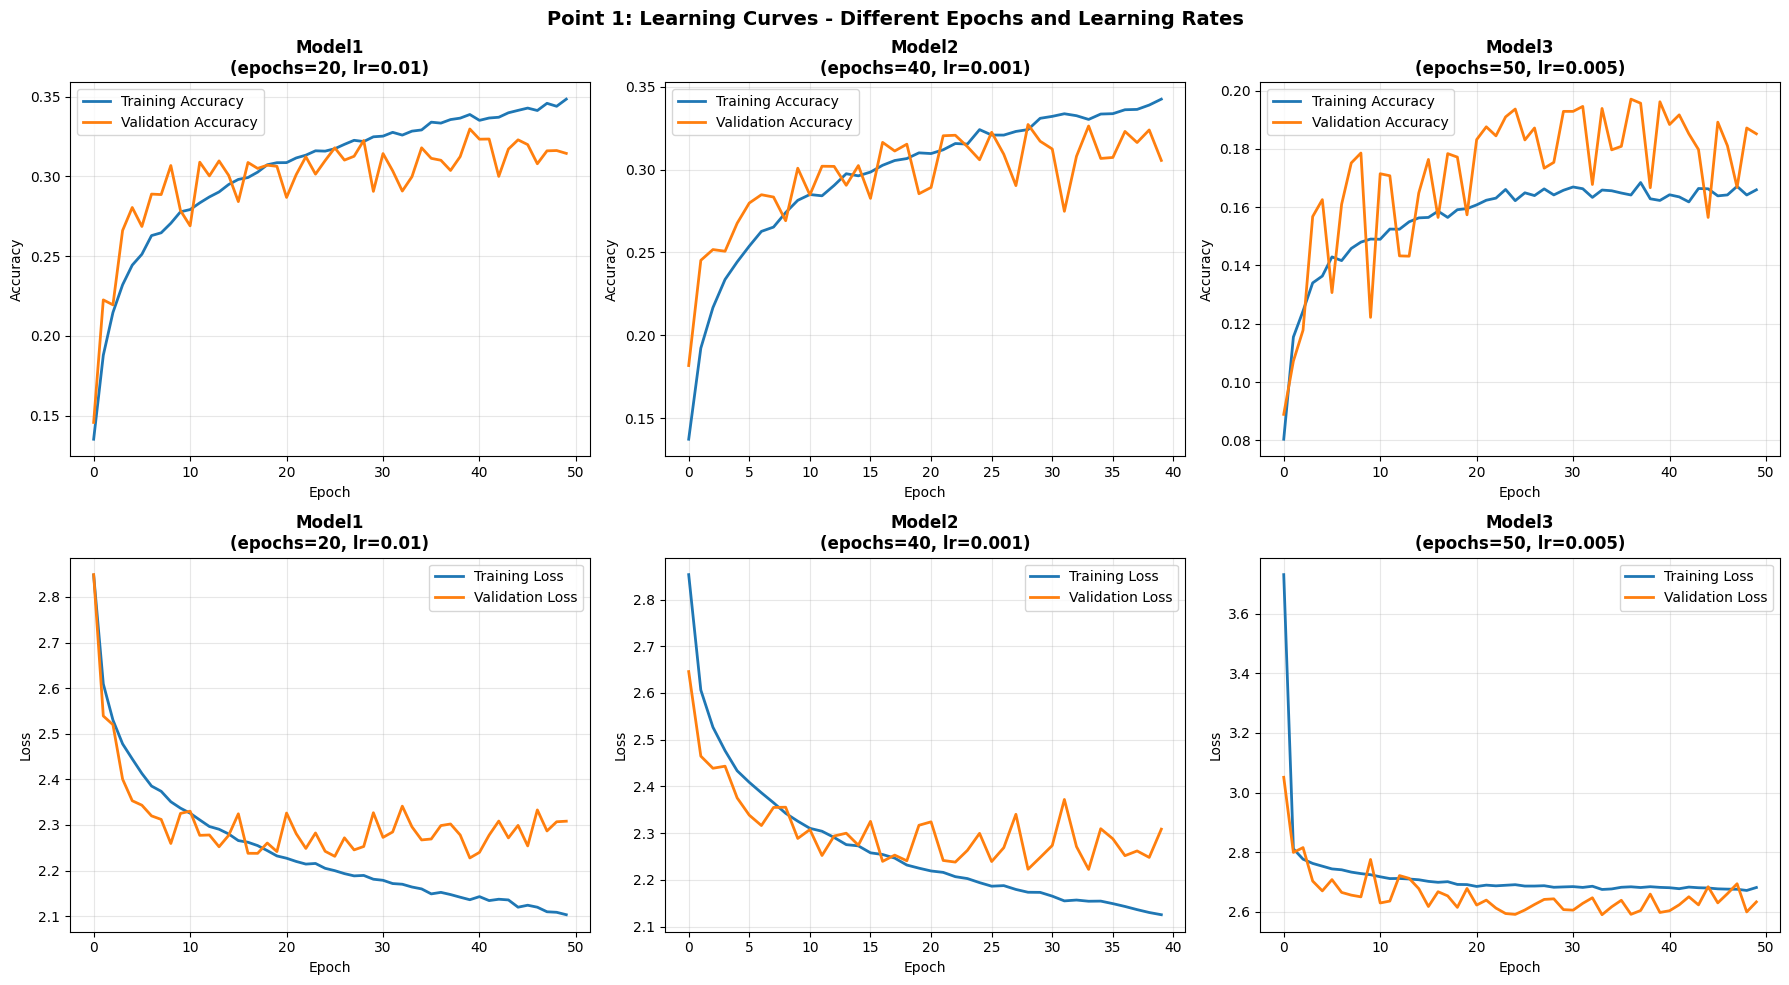


POINT 1 - Summary: Test Accuracy for Different Hyperparameters
Model                     Epochs     Learning Rate   Test Accuracy  
----------------------------------------------------------------------
Model 1                   20         0.01            0.3154
Model 2                   40         0.001           0.2999
Model 3                   50         0.005           0.1842


In [11]:
# Plot learning curves for all 3 models in Point 1
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Point 1: Learning Curves - Different Epochs and Learning Rates', fontsize=14, fontweight='bold')

models_names = ['Model1\n(epochs=20, lr=0.01)', 'Model2\n(epochs=40, lr=0.001)', 'Model3\n(epochs=50, lr=0.005)']
histories = [histories_point1['Model1'], histories_point1['Model2'], histories_point1['Model3']]

for idx, (hist, name) in enumerate(zip(histories, models_names)):
    # Accuracy plot
    axes[0, idx].plot(hist.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0, idx].plot(hist.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, idx].set_title(name, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1, idx].plot(hist.history['loss'], label='Training Loss', linewidth=2)
    axes[1, idx].plot(hist.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1, idx].set_title(name, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table of Point 1 results
print("\n" + "=" * 70)
print("POINT 1 - Summary: Test Accuracy for Different Hyperparameters")
print("=" * 70)
print(f"{'Model':<25} {'Epochs':<10} {'Learning Rate':<15} {'Test Accuracy':<15}")
print("-" * 70)
print(f"{'Model 1':<25} {'20':<10} {'0.01':<15} {test_scores_point1['Model1']:.4f}")
print(f"{'Model 2':<25} {'40':<10} {'0.001':<15} {test_scores_point1['Model2']:.4f}")
print(f"{'Model 3':<25} {'50':<10} {'0.005':<15} {test_scores_point1['Model3']:.4f}")
print("=" * 70)

## POINT 2: Advanced Training with Early Stopping and Data Augmentation (1.75 points)

### 2a. Implement Early Stopping with Keras Callbacks

Early stopping monitors validation loss and stops training when no improvement is observed for a specified number of epochs (patience).
This technique accelerates training and helps prevent overfitting.

In [ ]:
# Import early stopping and other callbacks
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint_callback = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

Early Stopping Configuration:
- Monitor: val_loss
- Patience: 5 epochs
- Restore best weights: True

When using early stopping, training will stop automatically
if there is no improvement in validation loss for 5 consecutive epochs.


### 2b. Design New MLP Architectures and Train with Early Stopping

We will create and train 3 models with different architectures:
- **Model 1 (Deep):** 4 hidden layers with decreasing neurons
- **Model 2 (Wide):** 2 hidden layers with more neurons
- **Model 3 (Standard):** 2 hidden layers with medium neurons

Each model will be trained with:
- Different learning rates and optimizers
- Early stopping to prevent overfitting
- Different batch sizes for optimization

#### 7.3. Visualize Some Predictions

This may give you some insight into why the network is misclassifying certain objects.

In [13]:
# Store models and histories for Point 2
models_point2 = {}
histories_point2 = {}
test_scores_point2 = {}

# Model 1: Deep Architecture with Adam optimizer and learning rate 0.001
print("=" * 70)
print("POINT 2: Model 1 - Deep Architecture with Early Stopping")
print("Architecture: 4 layers | Optimizer: Adam | Learning rate: 0.001")
print("=" * 70)

model_deep = build_mlp_model((32, 32, 3), num_classes, architecture='deep')
model_deep.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print(model_deep.summary())
hist_deep = model_deep.fit(
    x_train, y_train,
    batch_size=64,
    epochs=100,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[early_stop, checkpoint_callback]
)

models_point2['Deep'] = model_deep
histories_point2['Deep'] = hist_deep
score_deep = model_deep.evaluate(x_test, y_test, verbose=0)
test_scores_point2['Deep'] = score_deep[1]
epochs_trained_deep = len(hist_deep.history['loss'])

print(f"\nModel Deep - Epochs trained: {epochs_trained_deep}")
print(f"Model Deep - Test Accuracy: {score_deep[1]:.4f}")


POINT 2: Model 1 - Deep Architecture with Early Stopping
Architecture: 4 layers | Optimizer: Adam | Learning rate: 0.001


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,747,156 (6.66 MB)

 Trainable params: 1,747,156 (6.66 MB)

...


Epoch 8: finished saving model to best_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.2203 - loss: 2.5127 - val_accuracy: 0.2465 - val_loss: 2.4292
Epoch 9/100
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2191 - loss: 2.5049
Epoch 9: val_loss improved from 2.42920 to 2.41747, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.2215 - loss: 2.4986 - val_accuracy: 0.2513 - val_loss: 2.4175
Epoch 10/100
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2228 - loss: 2.4817
Epoch 10: val_loss did not improve from 2.41747
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.2259 - loss: 2.4815 - val_accuracy: 0.2547 - val_loss: 2.4259
Epoch 11/100
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2322 - loss: 2.4740
Epoch 11: val_loss did not improve from 2.41747
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.2301 - loss: 2.4750 - val_accuracy: 0.2486 - val_loss: 2.4275
Epoch 12/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2325 - loss: 2.4627
Epoch 12: val_loss improved from 2.41747 to 2.41654, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.2331 - loss: 2.4616 - val_accuracy: 0.2507 - val_loss: 2.4165
Epoch 13/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2331 - loss: 2.4664
Epoch 13: val_loss improved from 2.41654 to 2.39634, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.2335 - loss: 2.4606 - val_accuracy: 0.2565 - val_loss: 2.3963
Epoch 14/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2389 - loss: 2.4462
Epoch 14: val_loss improved from 2.39634 to 2.35561, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.2377 - loss: 2.4541 - val_accuracy: 0.2705 - val_loss: 2.3556
Epoch 15/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2420 - loss: 2.4329
Epoch 15: val_loss did not improve from 2.35561
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.2392 - loss: 2.4433 - val_accuracy: 0.2748 - val_loss: 2.3780
Epoch 16/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2448 - loss: 2.4348
Epoch 16: val_loss did not improve from 2.35561
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - accuracy: 0.2416 - loss: 2.4386 - val_accuracy: 0.2707 - val_loss: 2.3762
Epoch 17/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2431 - loss: 2.4341
Epoch 17: val_loss did not improve from 2.35561
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.2419 - loss: 2.4340 - val_accuracy: 0.2682 - val_loss: 2.3876
Epoch 18/100
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accura

In [14]:
# Model 2: Wide Architecture with SGD optimizer and learning rate 0.01
print("\n" + "=" * 70)
print("POINT 2: Model 2 - Wide Architecture with Early Stopping")
print("Architecture: 2 wide layers | Optimizer: SGD | Learning rate: 0.01")
print("=" * 70)

model_wide = build_mlp_model((32, 32, 3), num_classes, architecture='wide')
model_wide.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    metrics=['accuracy']
)

hist_wide = model_wide.fit(
    x_train, y_train,
    batch_size=128,
    epochs=100,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[early_stop, checkpoint_callback]
)

models_point2['Wide'] = model_wide
histories_point2['Wide'] = hist_wide
score_wide = model_wide.evaluate(x_test, y_test, verbose=0)
test_scores_point2['Wide'] = score_wide[1]
epochs_trained_wide = len(hist_wide.history['loss'])

print(f"\nModel Wide - Epochs trained: {epochs_trained_wide}")
print(f"Model Wide - Test Accuracy: {score_wide[1]:.4f}")



POINT 2: Model 2 - Wide Architecture with Early Stopping
Architecture: 2 wide layers | Optimizer: SGD | Learning rate: 0.01
Epoch 1/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1241 - loss: 2.8472
Epoch 1: val_loss did not improve from 2.35561
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.1596 - loss: 2.7186 - val_accuracy: 0.2258 - val_loss: 2.5161
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2042 - loss: 2.5599
Epoch 2: val_loss did not improve from 2.35561
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.2132 - loss: 2.5402 - val_accuracy: 0.2637 - val_loss: 2.4244
Epoch 3/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2291 - loss: 2.4866
Epoch 3: val_loss did not improve from 2.35561
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.2324 - loss: 2.4767 - val_accuracy: 0.2677 - val_loss: 2.3993
Epoch 4/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2508 - loss: 2.4289
Epoch 4: val_loss did not


Epoch 5: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.2589 - loss: 2.3924 - val_accuracy: 0.2968 - val_loss: 2.3187
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2729 - loss: 2.3617
Epoch 6: val_loss improved from 2.31870 to 2.27245, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.2730 - loss: 2.3593 - val_accuracy: 0.3081 - val_loss: 2.2725
Epoch 7/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2815 - loss: 2.3237
Epoch 7: val_loss did not improve from 2.27245
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.2781 - loss: 2.3344 - val_accuracy: 0.3004 - val_loss: 2.2933
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2810 - loss: 2.3219
Epoch 8: val_loss improved from 2.27245 to 2.26900, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.2839 - loss: 2.3082 - val_accuracy: 0.3052 - val_loss: 2.2690
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2865 - loss: 2.2883
Epoch 9: val_loss improved from 2.26900 to 2.24926, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.2865 - loss: 2.2920 - val_accuracy: 0.3117 - val_loss: 2.2493
Epoch 10/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2960 - loss: 2.2776
Epoch 10: val_loss improved from 2.24926 to 2.21292, saving model to best_model.h5


...


Epoch 38: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.3964 - loss: 1.9207 - val_accuracy: 0.3722 - val_loss: 2.0477
Epoch 39/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3987 - loss: 1.9112
Epoch 39: val_loss improved from 2.04766 to 2.03789, saving model to best_model.h5



Epoch 39: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.3986 - loss: 1.9137 - val_accuracy: 0.3720 - val_loss: 2.0379
Epoch 40/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4030 - loss: 1.8956
Epoch 40: val_loss improved from 2.03789 to 2.03699, saving model to best_model.h5



Epoch 40: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4013 - loss: 1.9064 - val_accuracy: 0.3733 - val_loss: 2.0370
Epoch 41/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4096 - loss: 1.8829
Epoch 41: val_loss improved from 2.03699 to 2.03674, saving model to best_model.h5



Epoch 41: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4073 - loss: 1.8891 - val_accuracy: 0.3693 - val_loss: 2.0367
Epoch 42/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4134 - loss: 1.8779
Epoch 42: val_loss did not improve from 2.03674
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.4128 - loss: 1.8767 - val_accuracy: 0.3732 - val_loss: 2.0372
Epoch 43/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4084 - loss: 1.8808
Epoch 43: val_loss improved from 2.03674 to 2.02964, saving model to best_model.h5



Epoch 43: finished saving model to best_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4105 - loss: 1.8790 - val_accuracy: 0.3766 - val_loss: 2.0296
Epoch 44/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4134 - loss: 1.8626
Epoch 44: val_loss did not improve from 2.02964
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4107 - loss: 1.8756 - val_accuracy: 0.3761 - val_loss: 2.0426
Epoch 45/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4188 - loss: 1.8504
Epoch 45: val_loss did not improve from 2.02964
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4160 - loss: 1.8596 - val_accuracy: 0.3708 - val_loss: 2.0391
Epoch 46/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4183 - loss: 1.8472
Epoch 46: val_loss did not improve from 2.02964
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.4171 - loss: 1.8489 - val_accuracy: 0.3746 - val_loss: 2.0436
Epoch 47/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accura

In [15]:
# Model 3: Standard Architecture with Adam optimizer and learning rate 0.0005
print("\n" + "=" * 70)
print("POINT 2: Model 3 - Standard Architecture with Early Stopping")
print("Architecture: 2 layers | Optimizer: Adam | Learning rate: 0.0005")
print("=" * 70)

model_standard = build_mlp_model((32, 32, 3), num_classes, architecture='standard')
model_standard.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

hist_standard = model_standard.fit(
    x_train, y_train,
    batch_size=96,
    epochs=100,
    verbose=1,
    validation_data=(x_valid, y_valid),
    callbacks=[early_stop, checkpoint_callback]
)

models_point2['Standard'] = model_standard
histories_point2['Standard'] = hist_standard
score_standard = model_standard.evaluate(x_test, y_test, verbose=0)
test_scores_point2['Standard'] = score_standard[1]
epochs_trained_standard = len(hist_standard.history['loss'])

print(f"\nModel Standard - Epochs trained: {epochs_trained_standard}")
print(f"Model Standard - Test Accuracy: {score_standard[1]:.4f}")



POINT 2: Model 3 - Standard Architecture with Early Stopping
Architecture: 2 layers | Optimizer: Adam | Learning rate: 0.0005
Epoch 1/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1263 - loss: 2.8381
Epoch 1: val_loss did not improve from 2.02964
417/417 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1549 - loss: 2.7225 - val_accuracy: 0.2144 - val_loss: 2.5524
Epoch 2/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2036 - loss: 2.5717
Epoch 2: val_loss did not improve from 2.02964
417/417 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.2095 - loss: 2.5498 - val_accuracy: 0.2582 - val_loss: 2.4397
Epoch 3/100
415/417 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2235 - loss: 2.5009
Epoch 3: val_loss did not improve from 2.02964
417/417 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.2300 - loss: 2.4842 - val_accuracy: 0.2687 - val_loss: 2.3665
Epoch 4/100
416/417 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2393 - loss: 2.4514
Epoch 4: val_loss did n

### 2b. Learning Curves Comparison with Early Stopping

Compare training curves for the three models with different architectures and optimizers.

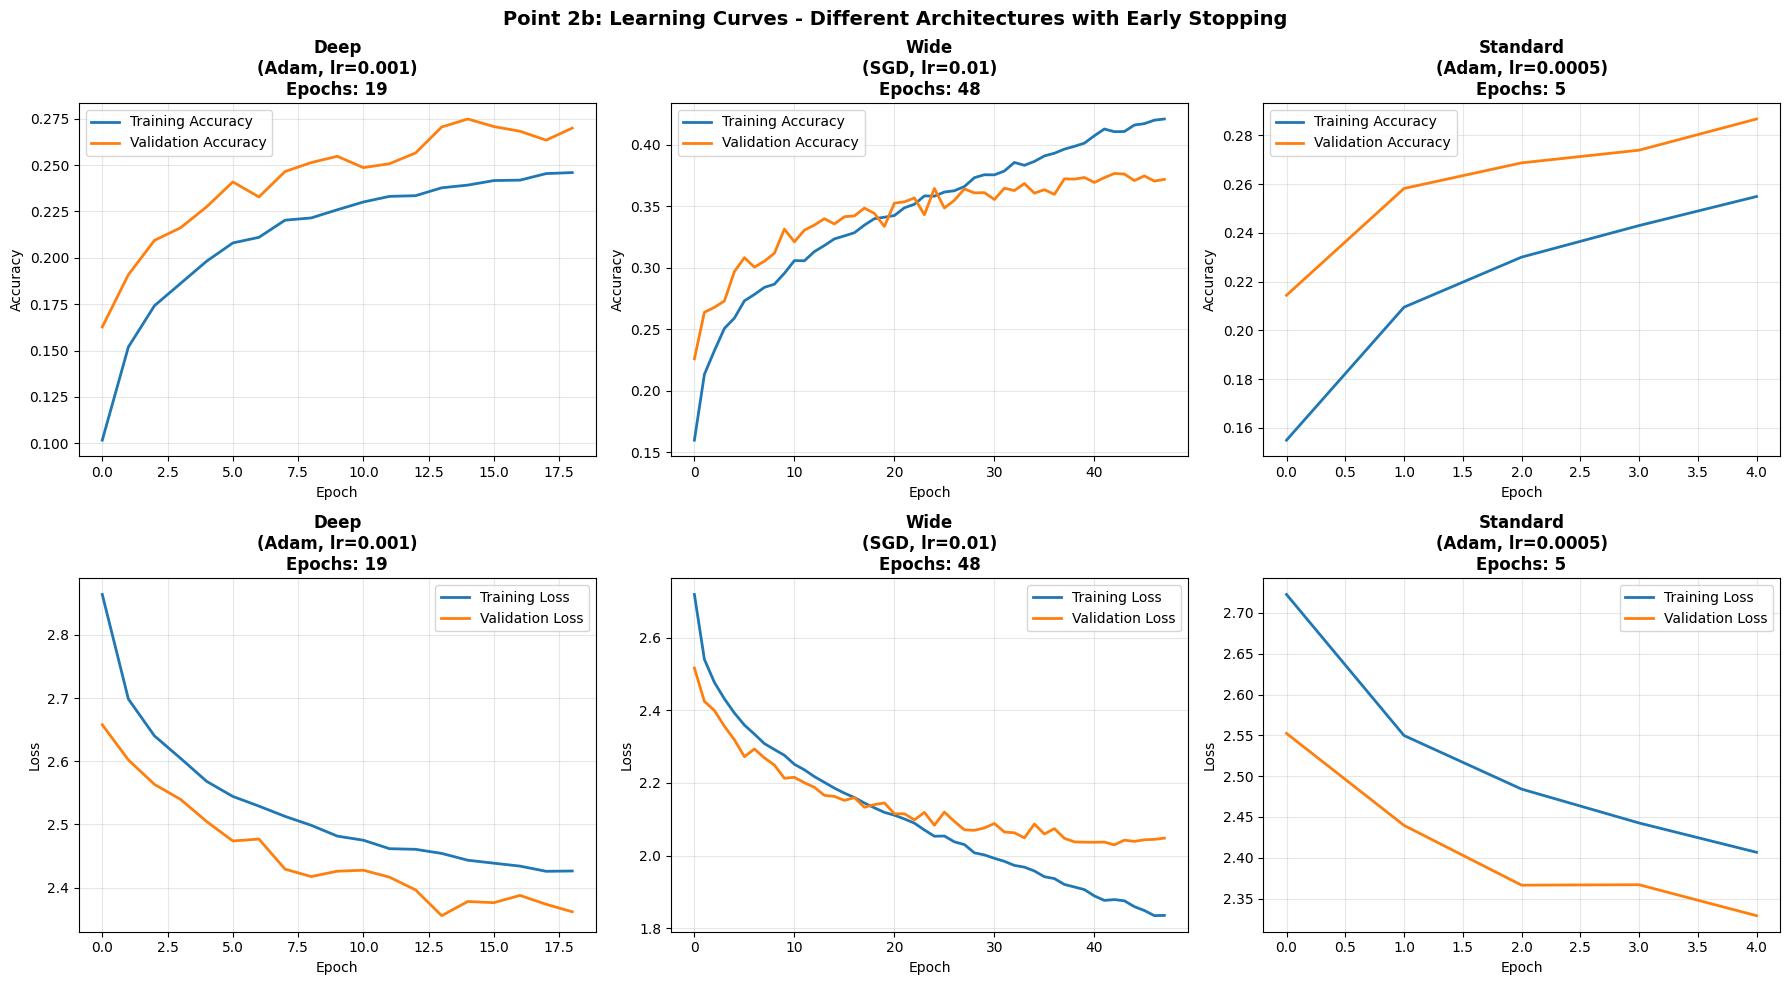


POINT 2b - Summary: Different Architectures with Early Stopping
Architecture         Optimizer            Learning Rate   Epochs     Test Acc  
--------------------------------------------------------------------------------
Deep                 Adam                 0.001           19         0.2586
Wide                 SGD                  0.01            48         0.3659
Standard             Adam                 0.0005          5          0.2076


In [16]:
# Plot learning curves for all 3 models in Point 2 with Early Stopping
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Point 2b: Learning Curves - Different Architectures with Early Stopping', 
             fontsize=14, fontweight='bold')

models_names_p2 = [
    f"Deep\n(Adam, lr=0.001)\nEpochs: {epochs_trained_deep}",
    f"Wide\n(SGD, lr=0.01)\nEpochs: {epochs_trained_wide}",
    f"Standard\n(Adam, lr=0.0005)\nEpochs: {epochs_trained_standard}"
]
histories_p2 = [histories_point2['Deep'], histories_point2['Wide'], histories_point2['Standard']]

for idx, (hist, name) in enumerate(zip(histories_p2, models_names_p2)):
    # Accuracy plot
    axes[0, idx].plot(hist.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0, idx].plot(hist.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, idx].set_title(name, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1, idx].plot(hist.history['loss'], label='Training Loss', linewidth=2)
    axes[1, idx].plot(hist.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1, idx].set_title(name, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table for Point 2.b
print("\n" + "=" * 80)
print("POINT 2b - Summary: Different Architectures with Early Stopping")
print("=" * 80)
print(f"{'Architecture':<20} {'Optimizer':<20} {'Learning Rate':<15} {'Epochs':<10} {'Test Acc':<10}")
print("-" * 80)
print(f"{'Deep':<20} {'Adam':<20} {'0.001':<15} {epochs_trained_deep:<10} {test_scores_point2['Deep']:.4f}")
print(f"{'Wide':<20} {'SGD':<20} {'0.01':<15} {epochs_trained_wide:<10} {test_scores_point2['Wide']:.4f}")
print(f"{'Standard':<20} {'Adam':<20} {'0.0005':<15} {epochs_trained_standard:<10} {test_scores_point2['Standard']:.4f}")
print("=" * 80)

### 2c. Data Augmentation and Retraining Models

We will apply data augmentation transformations to the training data to increase dataset size and improve model generalization.
The augmentation includes:
- **Rotation:** Random rotation up to 20 degrees
- **Width/Height Shift:** Random translation (0-20% of image size)
- **Horizontal Flip:** Random horizontal mirroring
- **Zoom:** Random zoom (0-20%)

After augmentation, we retrain all three models (Deep, Wide, Standard) with the augmented training data.

In [17]:
# Store models trained with data augmentation
models_point2c = {}
histories_point2c = {}
test_scores_point2c = {}

# Train model with data augmentation - Deep Architecture
print("=" * 70)
print("POINT 2c: Training Deep Model with Data Augmentation")
print("=" * 70)

# Reset early stopping for new training
early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_deep_aug = build_mlp_model((32, 32, 3), num_classes, architecture='deep')
model_deep_aug.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Train with augmented data using fit method with datagen
hist_deep_aug = model_deep_aug.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    batch_size=64,
    epochs=100,
    verbose=1,
    validation_data=(x_valid, y_valid),
    steps_per_epoch=len(x_train) // 64,
    callbacks=[early_stop_aug]
)

models_point2c['Deep'] = model_deep_aug
histories_point2c['Deep'] = hist_deep_aug
score_deep_aug = model_deep_aug.evaluate(x_test, y_test, verbose=0)
test_scores_point2c['Deep'] = score_deep_aug[1]
epochs_trained_deep_aug = len(hist_deep_aug.history['loss'])

print(f"\nDeep Model with Augmentation - Epochs trained: {epochs_trained_deep_aug}")
print(f"Deep Model with Augmentation - Test Accuracy: {score_deep_aug[1]:.4f}")


POINT 2c: Training Deep Model with Data Augmentation
Epoch 1/100


I0000 00:00:1773134880.327510   10133 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.0968 - loss: 2.8784 - val_accuracy: 0.1712 - val_loss: 2.6877
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.1441 - loss: 2.7278 - val_accuracy: 0.1774 - val_loss: 2.6234
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.1644 - loss: 2.6743 - val_accuracy: 0.1937 - val_loss: 2.5714
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.1754 - loss: 2.6412 - val_accuracy: 0.2107 - val_loss: 2.5590
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.1812 - loss: 2.6163 - val_accuracy: 0.2225 - val_loss: 2.5224
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.1866 - loss: 2.5992 - val_accuracy: 0.2252 - val_loss: 2.5260
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.1933 - loss: 2.5863 - val_accuracy: 0.2317 - val_loss: 2.4757
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.1964 - loss: 2.5741 - val_

In [18]:
# Train model with data augmentation - Wide Architecture
print("\n" + "=" * 70)
print("POINT 2c: Training Wide Model with Data Augmentation")
print("=" * 70)

model_wide_aug = build_mlp_model((32, 32, 3), num_classes, architecture='wide')
model_wide_aug.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    metrics=['accuracy']
)

hist_wide_aug = model_wide_aug.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    batch_size=128,
    epochs=100,
    verbose=1,
    validation_data=(x_valid, y_valid),
    steps_per_epoch=len(x_train) // 128,
    callbacks=[early_stop_aug]
)

models_point2c['Wide'] = model_wide_aug
histories_point2c['Wide'] = hist_wide_aug
score_wide_aug = model_wide_aug.evaluate(x_test, y_test, verbose=0)
test_scores_point2c['Wide'] = score_wide_aug[1]
epochs_trained_wide_aug = len(hist_wide_aug.history['loss'])

print(f"\nWide Model with Augmentation - Epochs trained: {epochs_trained_wide_aug}")
print(f"Wide Model with Augmentation - Test Accuracy: {score_wide_aug[1]:.4f}")



POINT 2c: Training Wide Model with Data Augmentation


/home/ervin/Videos/taller-1-/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.1436 - loss: 2.7557 - val_accuracy: 0.2075 - val_loss: 2.5707
Epoch 2/100
  1/312 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.1562 - loss: 2.7231

/home/ervin/Videos/taller-1-/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1562 - loss: 2.7231 - val_accuracy: 0.2123 - val_loss: 2.5740
Epoch 3/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.1936 - loss: 2.5956 - val_accuracy: 0.2422 - val_loss: 2.4633
Epoch 4/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2969 - loss: 2.4995 - val_accuracy: 0.2457 - val_loss: 2.4594
Epoch 5/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.2123 - loss: 2.5359 - val_accuracy: 0.2591 - val_loss: 2.4108
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.

Wide Model with Augmentation - Epochs trained: 5
Wide Model with Augmentation - Test Accuracy: 0.2055


In [19]:
# Train model with data augmentation - Standard Architecture
print("\n" + "=" * 70)
print("POINT 2c: Training Standard Model with Data Augmentation")
print("=" * 70)

model_standard_aug = build_mlp_model((32, 32, 3), num_classes, architecture='standard')
model_standard_aug.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

hist_standard_aug = model_standard_aug.fit(
    datagen.flow(x_train, y_train, batch_size=96),
    batch_size=96,
    epochs=100,
    verbose=1,
    validation_data=(x_valid, y_valid),
    steps_per_epoch=len(x_train) // 96,
    callbacks=[early_stop_aug]
)

models_point2c['Standard'] = model_standard_aug
histories_point2c['Standard'] = hist_standard_aug
score_standard_aug = model_standard_aug.evaluate(x_test, y_test, verbose=0)
test_scores_point2c['Standard'] = score_standard_aug[1]
epochs_trained_standard_aug = len(hist_standard_aug.history['loss'])

print(f"\nStandard Model with Augmentation - Epochs trained: {epochs_trained_standard_aug}")
print(f"Standard Model with Augmentation - Test Accuracy: {score_standard_aug[1]:.4f}")



POINT 2c: Training Standard Model with Data Augmentation
Epoch 1/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.1436 - loss: 2.7582 - val_accuracy: 0.2044 - val_loss: 2.5728
Epoch 2/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2188 - loss: 2.5602 - val_accuracy: 0.2044 - val_loss: 2.5799
Epoch 3/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.1960 - loss: 2.5922 - val_accuracy: 0.2399 - val_loss: 2.4575
Epoch 4/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1562 - loss: 2.6413 - val_accuracy: 0.2445 - val_loss: 2.4514
Epoch 5/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.2090 - loss: 2.5405 - val_accuracy: 0.2633 - val_loss: 2.3978
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.

Standard Model with Augmentation - Epochs trained: 5
Standard Model with Augmentation - Test Accuracy: 0.1982


### 2c. Learning Curves with Data Augmentation

Comparison of learning curves for models trained with data augmentation.

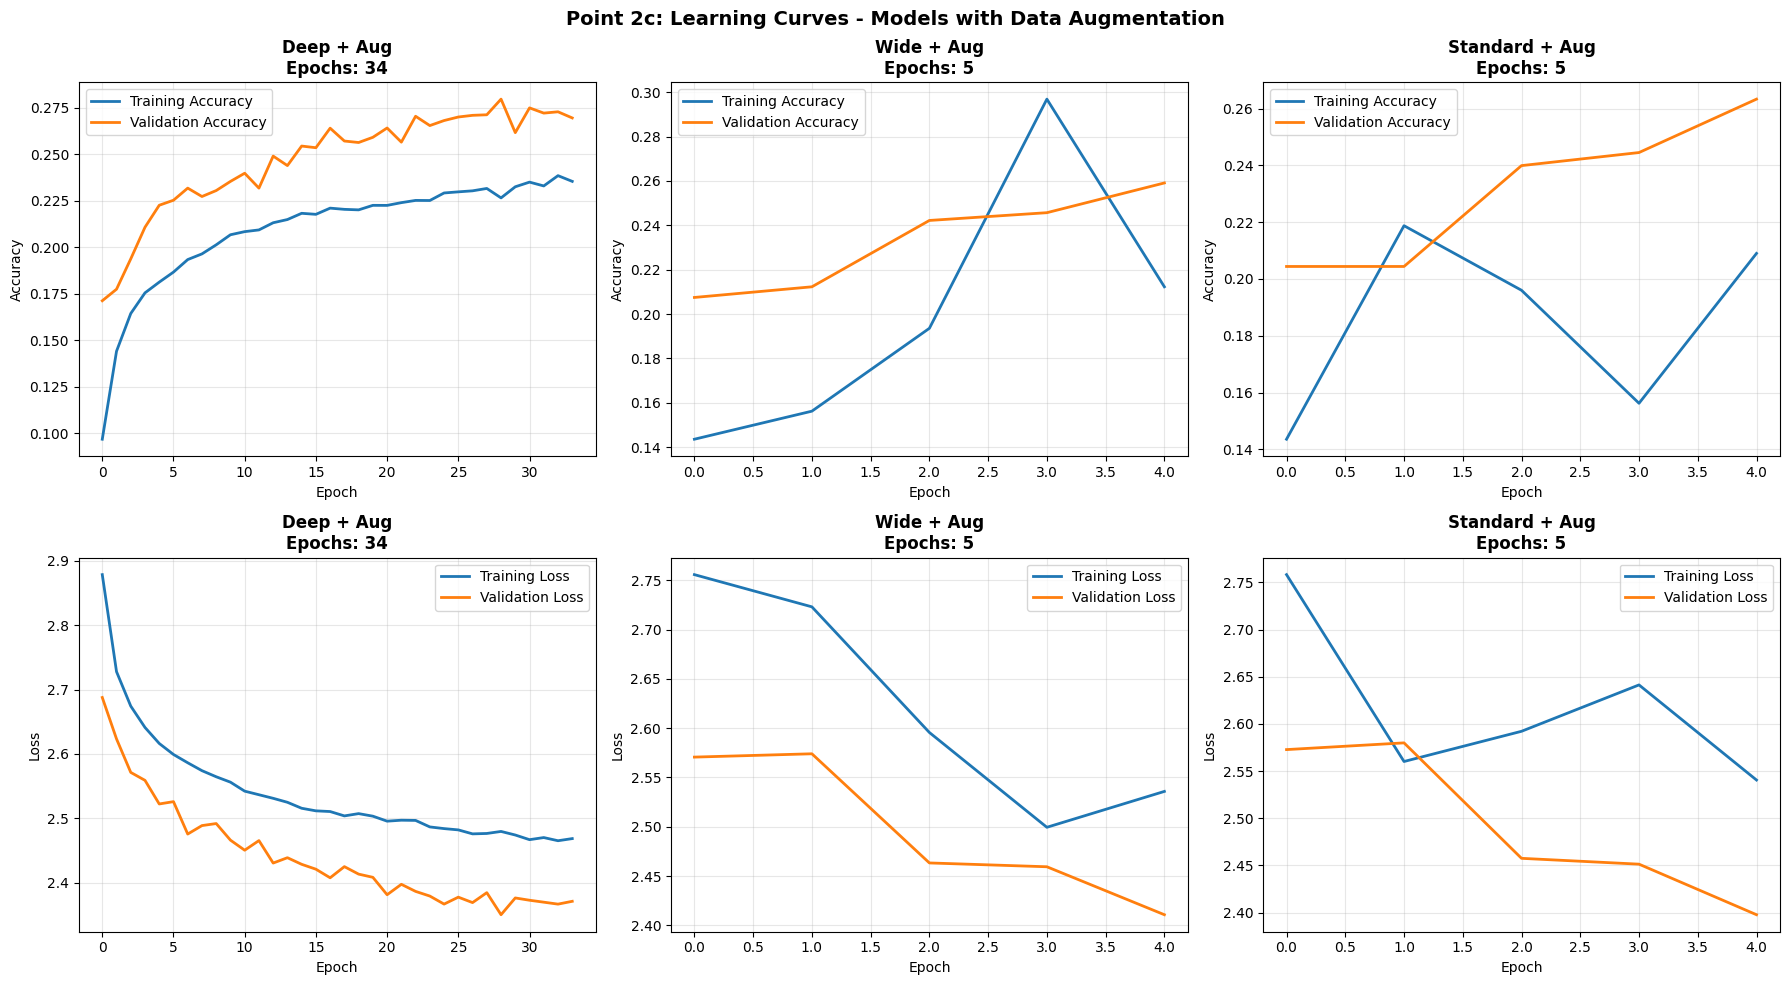


POINT 2c - Summary: Models Trained with Data Augmentation
Architecture         Epochs     Test Accuracy  
--------------------------------------------------------------------------------
Deep + Augmentation  34         0.2763
Wide + Augmentation  5          0.2055
Standard + Augmentation 5          0.1982


In [20]:
# Plot learning curves for all 3 models with Data Augmentation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Point 2c: Learning Curves - Models with Data Augmentation', 
             fontsize=14, fontweight='bold')

models_names_aug = [
    f"Deep + Aug\nEpochs: {epochs_trained_deep_aug}",
    f"Wide + Aug\nEpochs: {epochs_trained_wide_aug}",
    f"Standard + Aug\nEpochs: {epochs_trained_standard_aug}"
]
histories_aug = [histories_point2c['Deep'], histories_point2c['Wide'], histories_point2c['Standard']]

for idx, (hist, name) in enumerate(zip(histories_aug, models_names_aug)):
    # Accuracy plot
    axes[0, idx].plot(hist.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0, idx].plot(hist.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, idx].set_title(name, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1, idx].plot(hist.history['loss'], label='Training Loss', linewidth=2)
    axes[1, idx].plot(hist.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1, idx].set_title(name, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("POINT 2c - Summary: Models Trained with Data Augmentation")
print("=" * 80)
print(f"{'Architecture':<20} {'Epochs':<10} {'Test Accuracy':<15}")
print("-" * 80)
print(f"{'Deep + Augmentation':<20} {epochs_trained_deep_aug:<10} {test_scores_point2c['Deep']:.4f}")
print(f"{'Wide + Augmentation':<20} {epochs_trained_wide_aug:<10} {test_scores_point2c['Wide']:.4f}")
print(f"{'Standard + Augmentation':<20} {epochs_trained_standard_aug:<10} {test_scores_point2c['Standard']:.4f}")
print("=" * 80)

### 2d. Comprehensive Comparison and Conclusions

Complete comparison of all models trained with different architectures, optimizers, and with/without data augmentation.

In [21]:
import pandas as pd

# Create comprehensive comparison dataframe
comparison_data = {
    'Model': ['Deep (no aug)', 'Wide (no aug)', 'Standard (no aug)', 
              'Deep (aug)', 'Wide (aug)', 'Standard (aug)'],
    'Architecture': ['Deep', 'Wide', 'Standard', 'Deep', 'Wide', 'Standard'],
    'Data Augmentation': ['No', 'No', 'No', 'Yes', 'Yes', 'Yes'],
    'Epochs Trained': [epochs_trained_deep, epochs_trained_wide, epochs_trained_standard,
                       epochs_trained_deep_aug, epochs_trained_wide_aug, epochs_trained_standard_aug],
    'Test Accuracy': [test_scores_point2['Deep'], test_scores_point2['Wide'], test_scores_point2['Standard'],
                      test_scores_point2c['Deep'], test_scores_point2c['Wide'], test_scores_point2c['Standard']]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "=" * 90)
print("POINT 2d - COMPREHENSIVE COMPARISON TABLE")
print("=" * 90)
print(df_comparison.to_string(index=False))
print("=" * 90)

# Calculate improvements
print("\n" + "=" * 90)
print("IMPACT OF DATA AUGMENTATION (Test Accuracy Improvement)")
print("=" * 90)
for architecture in ['Deep', 'Wide', 'Standard']:
    no_aug = df_comparison[(df_comparison['Architecture'] == architecture) & 
                           (df_comparison['Data Augmentation'] == 'No')]['Test Accuracy'].values[0]
    with_aug = df_comparison[(df_comparison['Architecture'] == architecture) & 
                             (df_comparison['Data Augmentation'] == 'Yes')]['Test Accuracy'].values[0]
    improvement = (with_aug - no_aug) * 100
    improvement_pct = (improvement / no_aug) * 100
    print(f"{architecture:<15}: {no_aug:.4f} → {with_aug:.4f} (Δ = {improvement:+.4f}, {improvement_pct:+.2f}%)")
print("=" * 90)

# Best performing model
best_idx = df_comparison['Test Accuracy'].idxmax()
best_model = df_comparison.loc[best_idx]
print(f"\n{'BEST PERFORMING MODEL':<40} : {best_model['Model']}")
print(f"{'Test Accuracy':<40} : {best_model['Test Accuracy']:.4f}")
print(f"{'Epochs Trained (Early Stopping)':<40} : {int(best_model['Epochs Trained'])}")
print("=" * 90)



POINT 2d - COMPREHENSIVE COMPARISON TABLE
            Model Architecture Data Augmentation  Epochs Trained  Test Accuracy
    Deep (no aug)         Deep                No              19         0.2586
    Wide (no aug)         Wide                No              48         0.3659
Standard (no aug)     Standard                No               5         0.2076
       Deep (aug)         Deep               Yes              34         0.2763
       Wide (aug)         Wide               Yes               5         0.2055
   Standard (aug)     Standard               Yes               5         0.1982

IMPACT OF DATA AUGMENTATION (Test Accuracy Improvement)
Deep           : 0.2586 → 0.2763 (Δ = +1.7700, +684.46%)
Wide           : 0.3659 → 0.2055 (Δ = -16.0400, -4383.71%)
Standard       : 0.2076 → 0.1982 (Δ = -0.9400, -452.79%)

BEST PERFORMING MODEL                    : Wide (no aug)
Test Accuracy                            : 0.3659
Epochs Trained (Early Stopping)          : 48
